In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")

In [3]:
train_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Graduate,education_ Not Graduate,self_employed_ No,self_employed_ Yes,target
0,5,0.583333,1.120879,6,-0.119250,0.021978,1.632,0.090909,0.893617,0.0,1.0,1.0,0.0,0
1,0,0.937500,1.421245,12,0.364566,2.000000,1.056,1.643357,0.702128,0.0,1.0,0.0,1.0,0
2,1,-0.895833,-0.857143,8,0.269165,-0.373626,-0.416,-0.818182,-0.808511,1.0,0.0,1.0,0.0,0
3,2,-0.041667,-0.109890,18,0.514480,0.285714,-0.064,0.132867,0.574468,1.0,0.0,0.0,1.0,0
4,5,-0.437500,-0.256410,12,-0.551959,0.318681,-0.192,-0.510490,-0.531915,1.0,0.0,0.0,1.0,1


In [3]:
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=9)

In [22]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [23]:
y_pred = dt.predict(X_test)

In [24]:
# Max-Depth = 9

from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       536
           1       0.97      0.95      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

0.9695550351288056


In [19]:
# Max Depth = 0

from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

0.9742388758782201


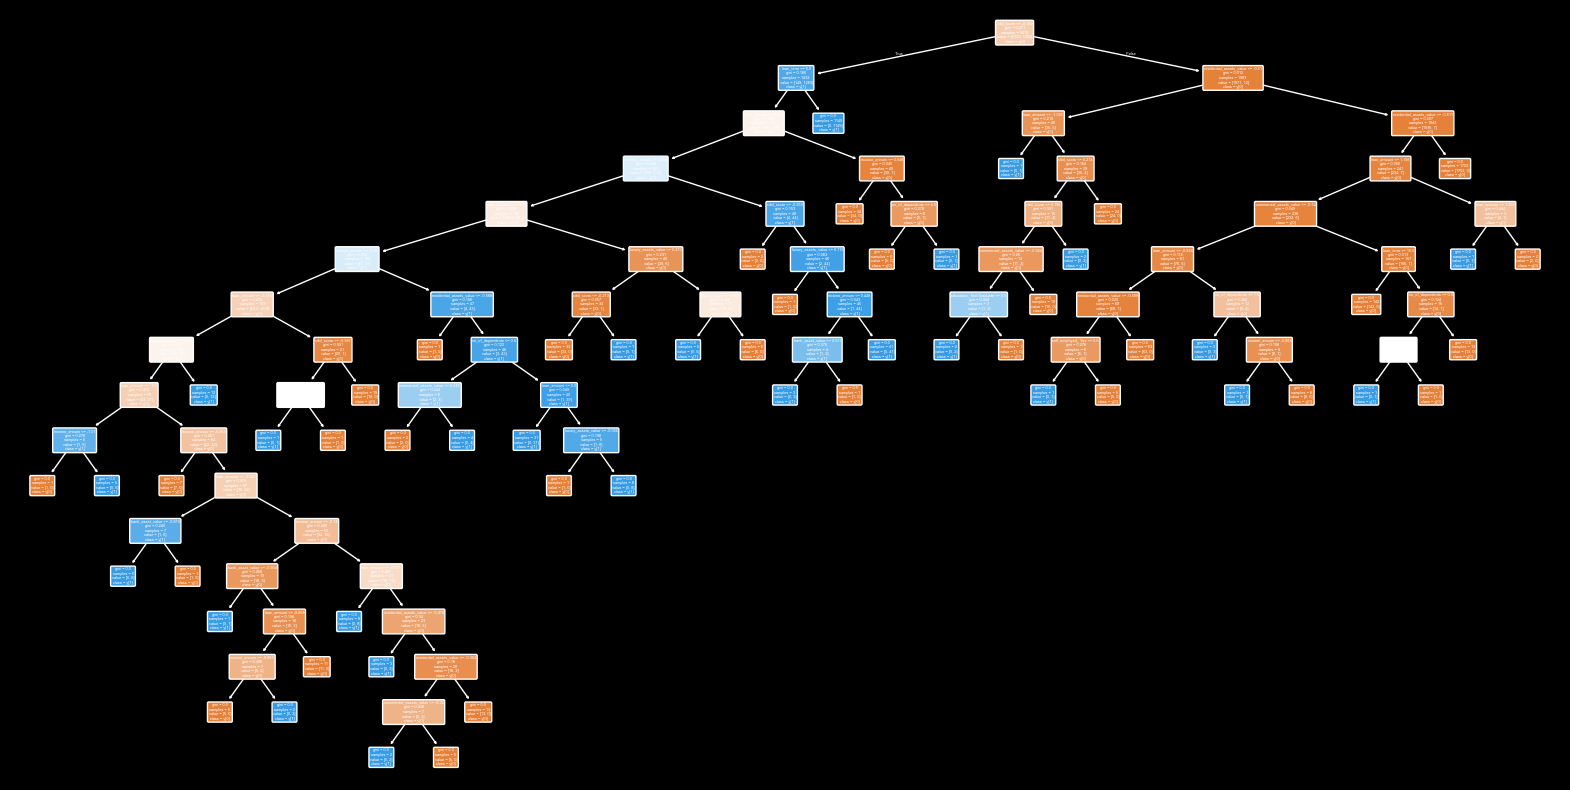

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    dt,                # your trained decision tree model
    feature_names=X_train.columns, # feature names
    class_names=True,        # for classification
    filled=True,
    rounded=True
)
plt.show()

[Text(0.6481119791666666, 0.9705882352941176, 'x[4] <= -0.182\ngini = 0.471\nsamples = 3415\nvalue = [2120, 1295]'),
 Text(0.5071614583333334, 0.9117647058823529, 'x[3] <= 5.0\ngini = 0.186\nsamples = 1432\nvalue = [149, 1283]'),
 Text(0.57763671875, 0.9411764705882353, 'True  '),
 Text(0.486328125, 0.8529411764705882, 'x[2] <= 0.853\ngini = 0.499\nsamples = 283\nvalue = [149, 134]'),
 Text(0.41015625, 0.7941176470588235, 'x[1] <= 0.406\ngini = 0.496\nsamples = 243\nvalue = [110, 133]'),
 Text(0.3203125, 0.7352941176470589, 'x[2] <= 0.106\ngini = 0.496\nsamples = 195\nvalue = [106.0, 89.0]'),
 Text(0.22395833333333334, 0.6764705882352942, 'x[1] <= -0.26\ngini = 0.494\nsamples = 150\nvalue = [67, 83]'),
 Text(0.15625, 0.6176470588235294, 'x[2] <= -0.315\ngini = 0.475\nsamples = 103\nvalue = [63.0, 40.0]'),
 Text(0.10416666666666667, 0.5588235294117647, 'x[1] <= -0.49\ngini = 0.499\nsamples = 82\nvalue = [43, 39]'),
 Text(0.08333333333333333, 0.5, 'x[2] <= -1.0\ngini = 0.474\nsamples = 7

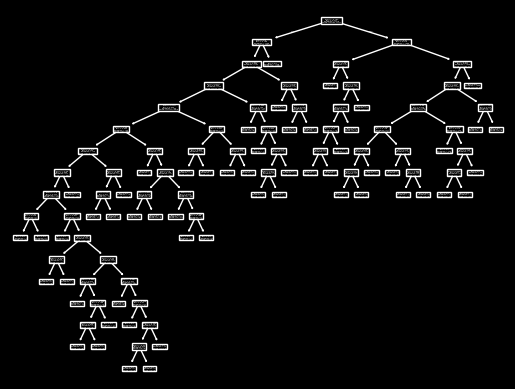

In [17]:
from sklearn import tree
tree.plot_tree(dt)

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



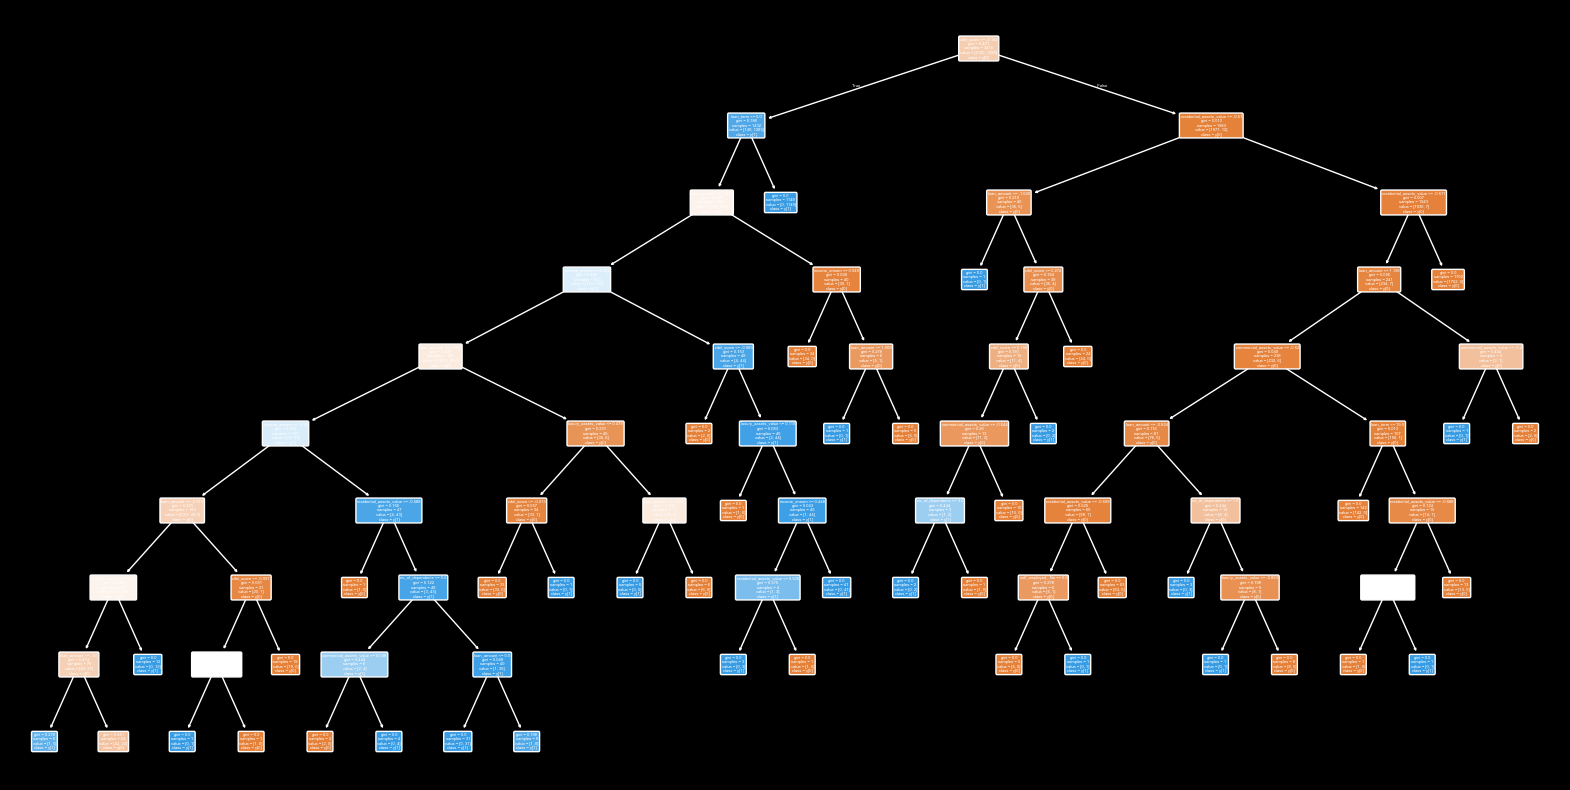

In [25]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,                # your trained decision tree model
    feature_names=X_train.columns, # feature names
    class_names=True,        # for classification
    filled=True,
    rounded=True
)
plt.show()

## Cross Validation

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.98243045 0.96925329 0.97218155 0.96486091 0.9795022 ]
Mean Accuracy: 0.9736456808199122


## Hyperparameter Tunning

## Grid Search Cv

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ['gini', 'entropy', 'log_loss'],
    "max_depth": [5, 7, 8, 9, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 8],
    "ccp_alpha": [0.0, 0.001, 0.01]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Score:
0.9815519765739384


## Random Search CV

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "ccp_alpha": [0, 0.001, 0.01]
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'min_samples_split': 10, 'min_samples_leaf': 8, 'max_depth': None, 'ccp_alpha': 0}
0.9789165446559297
